In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
from hydra import compose, initialize
from hydra.utils import instantiate
from omegaconf import open_dict
from sklearn.decomposition import PCA
from tqdm.auto import tqdm

from boa.model.module import ChgLightningModule

from mldft.ml.data.components.convert_transforms import ToTorch
from mldft.ml.data.components.of_data import Representation
from mldft.ml.models.components.loss_function import project_gradient
from mldft.utils.instantiators import instantiate_datamodule

In [2]:
device = "cuda"

with initialize(version_base=None, config_path="../configs"):
    config = compose(
        config_name="test.yaml",
        overrides=[
            "eval=qm9_pyscf_small",
            "data.datamodule.batch_size.val=1"
        ],
    )

basis_info = instantiate(config.data.basis_info)
datamodule_config = config.data.datamodule.copy()

datamodule = instantiate(datamodule_config, _recursive_=False)
datamodule.setup(stage="fit")

val_set = datamodule.val_dataset
train_set = datamodule.train_dataset
checkpoint_path = config.ckpt_path[0]
best_model_path = Path(config.ckpt_path[0]) / "best_model_path.txt"
if best_model_path.exists():
    # check if the best_model_path is different from the ckpt_path
    with open(best_model_path, "r") as f:
        best_ckpt_path = f.read().strip()
else:
    raise FileNotFoundError("Best model path not found")
lightning_module = ChgLightningModule.load_from_checkpoint(
    best_ckpt_path, map_location=device
)
lightning_module.eval()
print("Done")

Unique atom types: [1 6 7 8 9]
Using radial correction for GTOs.
Using radial correction for GTOs.
Using radial correction for GTOs.
Using radial correction for GTOs.
Using radial correction for GTOs.
self.linear_basis: False
Done


In [17]:
inputs = []
outputs = []
def hook_fn(module, input, output):
    inputs.append(input[0].detach().cpu())
    outputs.append(output.detach().cpu())
lightning_module.model.boa_stack.blocks[2].message_pass.register_forward_hook(hook_fn)

outputs_dict = {}
atom_keys = lightning_module.model.boa_stack.blocks[2].message_pass.inverse_mult_atoms.keys()
for key in atom_keys:
    atom_key = key
    print(atom_key)
    outputs_dict[atom_key] = ([], [])
    def hook_fn_a(module, input, output):
        outputs_dict[atom_key][0].append(input[0].detach().cpu())
        outputs_dict[atom_key][1].append(output.detach().cpu())
    lightning_module.model.boa_stack.blocks[2].message_pass.inverse_mult_atoms[atom_key].register_forward_hook(hook_fn_a)

1
6
7
8
9


In [18]:
from boa.model.module import get_probe_chunks

# Clear hook storage before running
inputs.clear()
outputs.clear()
for atom_key in atom_keys:
    outputs_dict[atom_key] = ([], [])

sample = next(iter(datamodule.val_dataloader())).to(device)
max_n_probe_per_pass = 10000

print(max_n_probe_per_pass)

# Run without gradient tracking to save memory
with torch.no_grad():
    coeffs, edge_index = lightning_module.model(sample)
    n_pass, n_per_pass, probes_to_process = get_probe_chunks(
        sample.n_probe, max_n_probe_per_pass
    )
    print(n_pass)
    all_preds = []
    for i_pass in range(n_pass):
        n_probe = n_per_pass[i_pass]
        probe_idx = probes_to_process[i_pass]
        probe_coords = sample.probe_coords[probe_idx]
        if lightning_module.linear_basis:
            coeffs_lin = torch.chunk(coeffs, 2, dim=-1)[0]
            pred = lightning_module.orbital_inference_linear(
                sample, coeffs_lin, n_probe, probe_coords, edge_index=edge_index
            )
        else:
            pred = lightning_module.orbital_inference(sample, coeffs, n_probe, probe_coords, edge_index=edge_index)
        all_preds.append(pred)

10000
tensor(110, device='cuda:0')


In [5]:
print(len(inputs), len(outputs))
print(inputs[0].shape, outputs[0].shape)

1 1
torch.Size([972, 32]) torch.Size([972, 32])


In [6]:
print("inputs", len(inputs), inputs[0].shape)
print("outputs", len(outputs), outputs[0].shape)
print("natoms", sample.atomic_numbers)

inputs 1 torch.Size([972, 32])
outputs 1 torch.Size([972, 32])
natoms tensor([8, 6, 6, 6, 6, 8, 6, 6, 8, 1, 1, 1, 1, 1, 1], device='cuda:0',
       dtype=torch.int32)


In [19]:
from pyscf import dft
from mldft.utils.molecules import build_molecule_ofdata

# build grid using meshgrid on a plane through three atoms
pos1 = sample.pos[0].cpu().detach().numpy()
pos2 = sample.pos[1].cpu().detach().numpy()
pos3 = sample.pos[2].cpu().detach().numpy()

# create a grid of points in the plane
grid_size = 100
grid_points = np.linspace(-3, 3, grid_size)
x, y = np.meshgrid(grid_points, grid_points)

# calculate the normal vector of the plane defined by the three points
normal_vector = np.cross(pos2 - pos1, pos3 - pos1)
normal_vector /= np.linalg.norm(normal_vector)
# calculate the center of the three points
center = (pos1 + pos2 + pos3) / 3
# rotate the grid points to align with the normal vector
rot_vec1 = pos2 - pos1
rot_vec1 /= np.linalg.norm(rot_vec1)
rot_vec2 = np.cross(rot_vec1, normal_vector)
rot_vec3 = normal_vector

rot_mat = np.array([rot_vec1, rot_vec2, rot_vec3]).T
print(sample.pos.shape)
print(sample.pos)
#pos = (rot_mat @ (sample.pos.detach().cpu().numpy() - center).T).T
grid_points = np.array([x.flatten(), y.flatten(), np.zeros_like(x.flatten())]).T
grid_points = (rot_mat @ grid_points.T).T + center

mol = build_molecule_ofdata(sample, basis_info.basis_dict)
ao = np.asarray(dft.numint.eval_ao(mol, grid_points, deriv=1))
print(ao.shape)
sample.add_item("ao", ao, representation=Representation.AO)

torch.Size([15, 3])
tensor([[4.1402, 6.9305, 4.1616],
        [4.1850, 5.5591, 4.0521],
        [3.9697, 4.7817, 2.7824],
        [3.0126, 4.6111, 3.9460],
        [3.6384, 3.7257, 5.0713],
        [4.9707, 3.3345, 4.7054],
        [4.7901, 4.6530, 5.1809],
        [2.9344, 3.0061, 6.1536],
        [3.4596, 2.2483, 6.9295],
        [4.9199, 7.2981, 3.7289],
        [3.5592, 5.3872, 1.9803],
        [4.6312, 3.9794, 2.4801],
        [1.9573, 4.8406, 3.8869],
        [5.3366, 4.9735, 6.0613],
        [1.8491, 3.2469, 6.2086]], device='cuda:0')
(4, 10000, 972)


Minimum distance between atoms and grid points: [0.02970826 0.02356675 0.02272996 1.17317401 0.82169588 0.53696527
 0.33063776 1.75677542 1.47991579 0.86647036 0.21889304 0.66944899
 2.18422432 0.7081226  2.81929736]


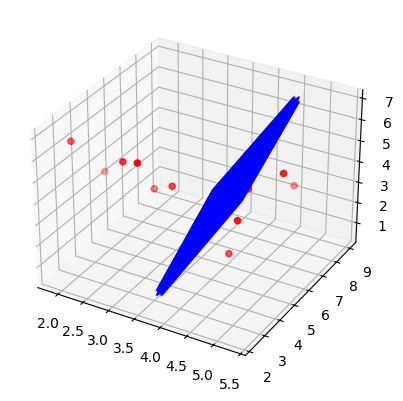

In [20]:
# plot atoms and grid points in 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
atom_pos = sample.pos.cpu().detach().numpy()
ax.scatter(atom_pos[:, 0], atom_pos[:, 1], atom_pos[:, 2], c='r', marker='o', label='Atoms')
ax.scatter(grid_points[:, 0], grid_points[:, 1], grid_points[:, 2], c='b', marker='x', label='Grid Points')

# print minimum distance between atoms and grid points
min_dist = np.min(np.linalg.norm(atom_pos[:, None, :] - grid_points[None, :, :], axis=-1), axis=1)
print("Minimum distance between atoms and grid points:", min_dist)

rot_pos = (rot_mat.T @ (sample.pos.detach().cpu().numpy() - center).T).T
rot_pos_xy = rot_pos[:, :2]

In [21]:
from matplotlib import cm
from mpl_toolkits.axes_grid1 import make_axes_locatable


def plot_2d(x, y, func, rot_pos_xy, scatter_kwargs, ax, label, atom_text, cbar=True, lims=None):
    if lims is None:
        lims = [np.min(func), np.max(func)]
    cf = ax.contourf(x, y, func.reshape(grid_size, grid_size), levels=100, vmin=lims[0], vmax=lims[1], cmap="viridis")
    cf.set_edgecolor("face")  
    # cbar that represents the whole color scale given by lims
    if cbar:
        # make cbar exaclty the same size as the plot
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=lims[0], vmax=lims[1])), cax=cax, fraction=0.1, pad=0.05)
    ax.scatter(rot_pos_xy[:, 0], rot_pos_xy[:, 1], **scatter_kwargs)
    # add text label to each atom
    for i, atom in enumerate(rot_pos_xy):
        ax.text(atom[0] + 0.1, atom[1] + 0.1, atom_text[i], fontsize=12, color="white")
    # add text label to the top left corner of the plot
    ax.text(0.05, 0.95, label, transform=ax.transAxes, fontsize=14,
            verticalalignment='top', color="white") #bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
    # remove ticks
    #make plot square
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])


In [29]:
from matplotlib import gridspec
from mldft.utils.molecules import numbers_to_element_symbols

# Verify that hooks captured data
if len(inputs) == 0 or len(outputs_a) == 0:
    raise RuntimeError("No hook data captured. Please re-run cell 4 to capture forward pass data.")

scatter_kwargs = {
    "s": 30,
    "alpha": 0.7,
    "color": "red",
    "linewidth": 1.0,
    "marker": "x",
}
atom_text = [numbers_to_element_symbols[atomic_number] for atomic_number in sample.atomic_numbers.cpu().detach().numpy()]

coeff_ind_to_node_ind = sample.coeff_ind_to_node_ind.cpu().detach().numpy()

# calculate feature functions on the grid
# Note: inputs and outputs_a are already on CPU from the hooks
features = inputs[0].numpy()
print(features.shape)
funcs = ao[0] @ features

s_funcs = ao[0, :, coeff_ind_to_node_ind == 0].T @ features[coeff_ind_to_node_ind == 0]

atom0 = str(sample.atomic_numbers[0].item())

output_feature = outputs_dict
print(output_feature)
# funcs_out = ao[0, :, coeff_ind_to_node_ind == 0].T @ output_feature[0]

(972, 32)
{'1': ([], []), '6': ([], []), '7': ([], []), '8': ([], []), '9': ([tensor([[[ 0.0268,  0.0399, -0.0029,  ...,  0.0005,  0.0143, -0.0001],
         [ 0.0114, -0.0251,  0.0042,  ..., -0.0390, -0.0042,  0.0193],
         [-0.0869, -0.0497, -0.0201,  ..., -0.0460, -0.0434,  0.0083],
         ...,
         [ 0.0226, -0.0086,  0.0347,  ...,  0.0046,  0.0043,  0.0138],
         [-0.0030,  0.0011, -0.0090,  ..., -0.0028, -0.0008, -0.0044],
         [-0.0039, -0.0043, -0.0034,  ..., -0.0244, -0.0084, -0.0013]],

        [[ 0.0014,  0.0237, -0.0209,  ...,  0.0138, -0.0019, -0.0174],
         [-0.0003, -0.0085,  0.0049,  ..., -0.0318, -0.0147,  0.0118],
         [-0.1023, -0.0015, -0.0132,  ..., -0.0405, -0.0792, -0.0208],
         ...,
         [-0.0161,  0.0022, -0.0355,  ...,  0.0087,  0.0045, -0.0164],
         [ 0.0057, -0.0005,  0.0232,  ...,  0.0022,  0.0074,  0.0151],
         [ 0.0060,  0.0033,  0.0137,  ..., -0.0144, -0.0106,  0.0043]],

        [[ 0.0169, -0.0025,  0.0206,  

In [ ]:
basis_info.basis_dim_per_atom

array([36, 83, 83, 86, 86])

In [ ]:
for ind in range(1):
    lims = (min(np.min(funcs[..., ind]), np.min(s_funcs[..., ind]), np.min(funcs_out[..., ind])),
            max(np.max(funcs[..., ind]), np.max(s_funcs[..., ind]), np.max(funcs_out[..., ind])))

    # Create a figure
    fig = plt.figure(figsize=(14, 4))

    # Create a GridSpec with 1 row and 2 columns for two groups of subplots
    gs_outer = gridspec.GridSpec(1, 2, width_ratios=[3.07, 1.07], wspace=0.1)  # Non-zero spacing between groups

    # First group: 3 subplots with zero spacing
    gs_first_three = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs_outer[0], wspace=0.00, width_ratios=[1, 1, 1.07])
    
    # Second group: 1 subplot
    gs_last = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=gs_outer[1])

    # Create axes
    ax = [
        fig.add_subplot(gs_first_three[0]),
        fig.add_subplot(gs_first_three[1]),
        fig.add_subplot(gs_first_three[2]),
        fig.add_subplot(gs_last[0])
    ]

    # Plotting
    plot_2d(x, y, funcs[..., ind], rot_pos_xy, scatter_kwargs, ax[0], "A", atom_text, cbar=False, lims=lims)
    plot_2d(x, y, s_funcs[..., ind], rot_pos_xy, scatter_kwargs, ax[1], "B", atom_text, cbar=False, lims=lims)
    plot_2d(x, y, funcs_out[..., ind], rot_pos_xy, scatter_kwargs, ax[2], "C", atom_text, cbar=True, lims=lims)

    # Plot diff
    plot_2d(x, y, funcs_out[..., ind] - s_funcs[..., ind], rot_pos_xy, scatter_kwargs, ax[3], "D", atom_text, cbar=True)

    plt.tight_layout()
    plt.savefig("/export/home/mklockow/sciai-dft/data/figures/feature_functions.pdf", dpi=300)
    plt.show()